# Using Machine Learning for Market Movement Prediction


## 1. 用 scikit-learn 做回归

使用 scikit-learn 主要包含三个步骤：

1. 模型选择：选定并实例化一个模型。
2. 模型拟合：将模型拟合到手头的数据。
3. 预测：基于拟合好的模型进行预测。


### 1.1 线性回归计算过程

如何将 scikit-learn 应用到之前线性回归的例子上？ 本 notebook 使用了 scikit-learn 里 `linear_model` 模块中的 `LinearRegression` 模型。默认情况下，它会拟合一个截距项：

In [1]:
import numpy as np
from sklearn import linear_model

x = np.arange(2, 12)   # 示例序列: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]，长度 10
lags = 3               # 用过去 3 期做滞后特征

In [2]:
m = np.zeros((lags + 1, len(x) - lags))  # 这里是 (4, 7)
m[lags] = x[lags:]     # 最后一行: 目标序列 x_t，从第 lags 个元素起 → [5,6,7,8,9,10,11]

for i in range(lags):
    m[i] = x[i:i - lags]

In [3]:
'''
假设 x 是一个等差数列，那么算出来的 m 就是：

         lag1       lag2       lag3            b
行0        2          3          4             5
行1        3          4          5             6
行2        4          5          6             7
...
行6        8          9         10            11


真实场景中，特征矩阵 A 可以包含我们认为可能对预测有用的各种特征（以及他们的 lag 序列），如

           |-------价格滞后------|  |-----对数收益滞后-----|  |------波动率滞后-----|    |真实值|
           P_t-1   P_t-2   P_t-3   r_t-1   r_t-2   r_t-3   σ_t-1   σ_t-2   σ_t-3      b
Day1        …       …       …        …       …       …      …       …       …         …
Day2        …       …       …        …       …       …      …       …       …         …
Day3        …       …       …        …       …       …      …       …       …         …

'''

m.T

array([[ 2.,  3.,  4.,  5.],
       [ 3.,  4.,  5.,  6.],
       [ 4.,  5.,  6.,  7.],
       [ 5.,  6.,  7.,  8.],
       [ 6.,  7.,  8.,  9.],
       [ 7.,  8.,  9., 10.],
       [ 8.,  9., 10., 11.]])

In [4]:
# b ≈ A · coef_ + intercept_

A = m[:lags].T # 前 lag-1 行，是历史
b = m[-1] # 最后一行，是当下

In [5]:
lm1 = linear_model.LinearRegression(fit_intercept=True)  # 带截距： b ≈ A @ coef_ + intercept_
lm1.fit(A, b)

print("coef_ = ", lm1.coef_)
print("intercept_ = ", lm1.intercept_)
# b_hat1 ≈ (-1/3)*lag1 + (1/3)*lag2 + (1/3)*lag3 + 2.0

coef_ =  [0.33333333 0.33333333 0.33333333]
intercept_ =  2.0


In [6]:
b_hat1 = lm1.predict(A)  # 预测的 b
print("b_hat1 = ", b_hat1)

b_hat1 =  [ 5.  6.  7.  8.  9. 10. 11.]


In [7]:
lm2 = linear_model.LinearRegression(fit_intercept=False)  # 不带截距：b ≈ A @ coef_
lm2.fit(A, b)

print("coef_ = ", lm2.coef_)
print("intercept_ = ", lm2.intercept_)
# b_hat2 ≈ (-2/3)*lag1 + (1/3)*lag2 + (4/3)*lag3 

coef_ =  [-0.66666667  0.33333333  1.33333333]
intercept_ =  0.0


In [8]:
b_hat2 = lm2.predict(A)
print("b_hat2 = ", b_hat2)

b_hat2 =  [ 5.  6.  7.  8.  9. 10. 11.]


### 1.2 为什么对比“带截距”和“不带截距”

对这个等差数列，两种设定都能几乎完美拟合，但系数的含义不一样：

- 带截距：截距单独承担序列的整体水平（这里应为 `2.0`），三个 lag 系数只需要表达“变化趋势”，所以它们符号一致、数值接近，可以正常解读。
- 不带截距：模型没有截距这个自由度，只能靠三个 lag 系数同时凑出“整体水平 + 变化趋势”。由于三个 lag 特征完全共线（同一个等差数列平移），这个方程组有无穷多组解都能拟合到零误差，系数因此会正负乱窜、相互抵消——这组系数不再有稳定、唯一的含义。

全零探针验证：给模型输入全零特征，带截距的模型会直接输出截距值，不带截距的模型则输出 0。

结论：模型拟合误差一样小，不代表系数可解释性一样。这个现象在这里被这个等差数列组成的玩具数据放大到了极致，真实行情的 lag 特征通常只是高度相关而非完全相同，不会这么极端，但道理相同 —— **特征强相关时，不能望文生义地解读单个系数**，这也是实际量化建模里常用 Ridge/Lasso 等正则化处理共线性的原因之一。

### 1.3 总结

本节使用一个简单的等差数列，已经很好地说明了如何将 scikit-learn 应用于预测问题。由于其一致的 API 设计，这套基本方法可以顺利地迁移到其他模型上。

## 2. 用 scikit-learn 做分类

预测明天市场涨跌，本质是分类问题：结果只能是“涨”或“跌”两类，不像回归那样是一个连续数值。

分类与回归的区别、以及为什么线性回归不适合这种 0/1 结果，这里不再展开推导. 可参考 [Wikipedia: Logistic regression 的示例](https://en.wikipedia.org/wiki/Logistic_regression#Example)（用学习时长预测考试是否通过，与本例思路一致）。

下面只用同一份示例数据快速过一遍 `LogisticRegression` 的用法，为后续预测市场方向做准备。

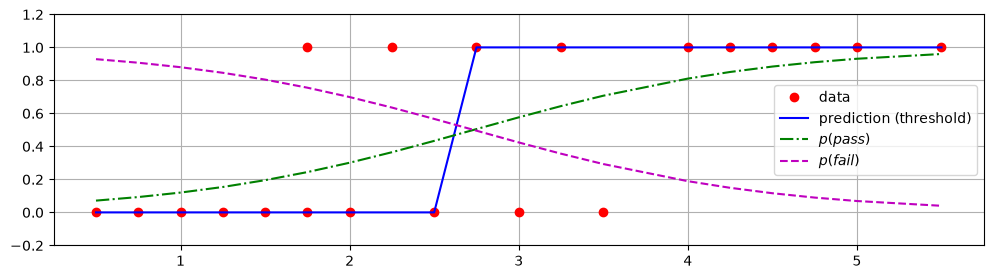

In [9]:
import matplotlib.pyplot as plt

# 各学生学习的小时数，以及是否通过考试（示例数据，来自 Wikipedia 逻辑回归词条）
hours = np.array([0.5, 0.75, 1., 1.25, 1.5, 1.75, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 4.0, 4.25, 4.5, 4.75, 5.0, 5.5])
success = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

lm = linear_model.LogisticRegression(solver='lbfgs')   # 实例化逻辑回归模型
hrs = hours.reshape(-1, 1)                              # scikit-learn 要求的二维输入
lm.fit(hrs, success)
prediction = lm.predict(hrs)          # 硬分类：0 或 1
prob = lm.predict_proba(hrs)          # 软分类：通过/不通过的概率（二者相加为 1）

plt.figure(figsize=(12, 3))
plt.plot(hours, success, 'ro', label='data')
plt.plot(hours, prediction, 'b', label='prediction (threshold)')
plt.plot(hours, prob.T[1], 'g-.', label='$p(pass)$')
plt.plot(hours, prob.T[0], 'm--', label='$p(fail)$')
plt.ylim(-0.2, 1.2)
plt.legend()
plt.grid(True)
plt.show()

`LogisticRegression` 的 API 和之前的 `LinearRegression` 完全一致（`fit` / `predict`），只是多了 `predict_proba` 可以拿到概率而不只是硬分类结果.

这一点在后续判断市场涨跌概率时会直接用到。

## 3. 用逻辑回归预测市场方向

机器学习里习惯管输入叫特征。前面的例子只有一个特征（即学习小时数）。实盘里通常会有很多特征。

本节用滞后收益作特征（如 lag1,lag2,lag3）；标签为涨跌方向：`+1` 表示上涨、`-1` 表示下跌。

---
本 notebook 的改动说明：

Hilpisch 原书示例因为篇幅原因，有几处口径并不统一。本笔记统一修改过，主要差别如下。

1. 特征统一用滞后收益，不用滞后价格。价格非平稳、共线强，直接拿价格的滞后值做回归特征，本质上是在拟合一条几乎共线的趋势线，系数不稳定、也没什么经济含义；收益率更接近平稳，使用滞后收益做回归特征, 是量化里的标准做法. 本章使用了 `market_return` 的3阶滞后和5阶滞后，来分析滞后阶数对回归效果的影响。

2. 训练与评估都坚持二分类：书里写法是：`fit` 时用 `np.sign(return)` 变成三类（1,0,-1），求命中率时又用 `mask` 丢掉 `0`，计算二分类的命中率。本 notebook 在拟合前就去掉 `market_return == 0` 的样本，只在 `±1` 上训练；评估命中率与 `log_loss` 也只在 `±1` 上计算。

3. 评估指标：除命中率外，增加训练目标 `log_loss`，并以此对照 `lags=3` 与 `lags=5`的效果。

---

In [10]:
import pandas as pd

raw = pd.read_csv(
    'data/pyalgo_eikon_eod_data.csv',
    index_col=0,
    parse_dates=True,
).dropna()

raw

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-04,30.572827,30.950,20.88,133.90,173.08,113.33,1132.99,20.04,1.4411,1120.0000,47.71,109.80
2010-01-05,30.625684,30.960,20.87,134.69,176.14,113.63,1136.52,19.35,1.4368,1118.6500,48.17,109.70
2010-01-06,30.138541,30.770,20.80,132.25,174.26,113.71,1137.14,19.16,1.4412,1138.5000,49.34,111.51
2010-01-07,30.082827,30.452,20.60,130.00,177.67,114.19,1141.69,19.06,1.4318,1131.9000,49.10,110.82
2010-01-08,30.282827,30.660,20.83,133.52,174.31,114.57,1144.98,18.13,1.4412,1136.1000,49.84,111.37
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,284.270000,157.380,59.41,1789.21,229.91,321.23,3223.38,12.67,1.1087,1498.8100,28.66,141.27
2019-12-26,289.910000,158.670,59.82,1868.77,231.21,322.94,3239.91,12.65,1.1096,1511.2979,29.08,142.38
2019-12-27,289.800000,158.960,60.08,1869.80,230.66,322.86,3240.02,13.43,1.1175,1510.4167,28.87,142.33


### 3.1 使用滞后收益特征做逻辑回归

In [11]:
from sklearn.metrics import accuracy_score, log_loss

def run_lag_logistic_strategy(raw, symbol, lags, plot_kind='cum_net', figsize=None):
    data = pd.DataFrame(raw[symbol]).rename(columns={symbol: 'price'})
    data['market_return'] = np.log(data['price'] / data['price'].shift(1))

    cols = []
    for lag in range(1, lags + 1):
        col = f'lag_{lag}'
        data[col] = data['market_return'].shift(lag)
        cols.append(col)
    data.dropna(inplace=True)         # 确保数据集完整

    # 二分类：只用有方向的样本训练（去掉 sign=0），与后面命中率/log_loss 口径一致
    y_true = np.sign(data['market_return'])
    mask = y_true != 0

    lm = linear_model.LogisticRegression(
        C=1e7,              # 正则化强度的倒数；越大正则越弱，这里几乎等于不惩罚
        solver='lbfgs',     # 优化算法；小到中等规模二分类常用 L-BFGS
        max_iter=1000,      # 最大迭代次数；不够会警告未收敛，可加大
    )
    lm.fit(data.loc[mask, cols], y_true.loc[mask])
    data['prediction'] = lm.predict(data[cols])   # 全样本给出仓位；收益为 0 的日子对策略损益贡献为 0

    y_pred = data['prediction']
    hit_ratio = accuracy_score(y_true[mask], y_pred[mask])

    proba = lm.predict_proba(data[cols])
    ll = log_loss(y_true[mask], proba[mask], labels=lm.classes_)

    data['strategy_return'] = data['prediction'] * data['market_return']

    cum_log_return = data[['market_return', 'strategy_return']].cumsum()  # 累计对数收益率
    cum_gross_return = np.exp(cum_log_return)                             # 累计毛收益率
    cum_net_return = cum_gross_return - 1                                 # 累计净收益率
    cum_net_return.plot(figsize=figsize or (12, 3), grid=True)

    return data, cols, lm, hit_ratio, ll


两种判断方向的思路：

- 回归后取预测值符号
- 直接把方向当分类标签训练。

本例分类命中率更高，因为它的训练目标本就是"方向对不对"，而回归优化的是"数值准不准"。但命中率不区分"判断对一次大涨"和"判断对一次小波动"，二者贡献相同，命中率高不代表策略净值更好（书中也提到这一点）。

下面按训练口径算命中率：dropna 后的有效样本，收益为 0 不参与判断。下图为分类策略表现：

### 3.2 对比三阶 lag 和 五阶 lag 的累计净收益率
把滞后期从 3 改为 5，观察策略收益会如何变化：

In [12]:
symbol = 'GLD'

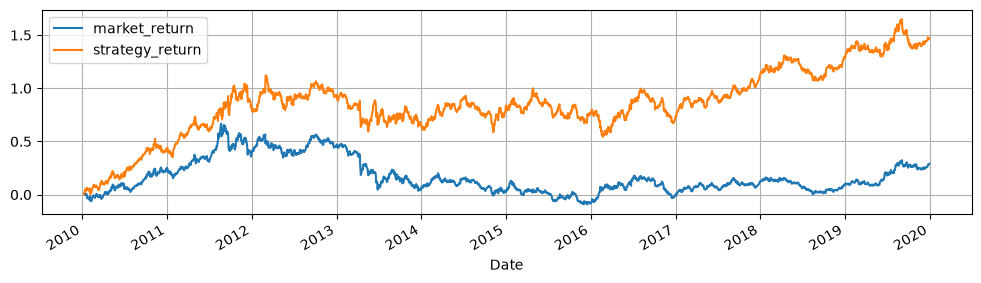

In [13]:
data3, cols3, lm3, hit3, ll3 = run_lag_logistic_strategy(
    raw, symbol, lags=3, plot_kind='cum_net',
)

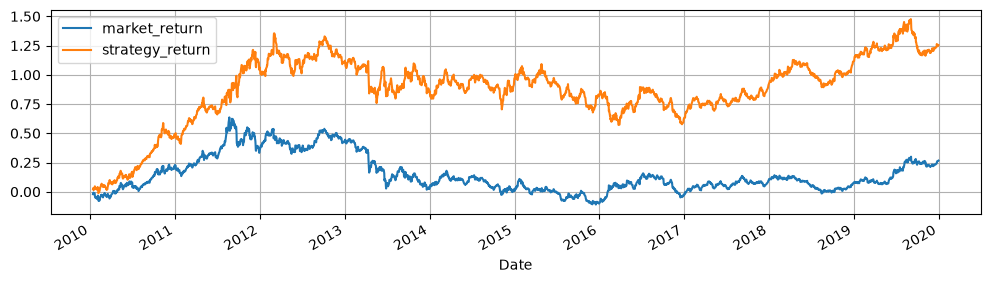

In [14]:
data5, cols5, lm5, hit5, ll5 = run_lag_logistic_strategy(
    raw, symbol, lags=5, plot_kind='cum_gross',
)

### 3.3 对比三阶 lag 和 五阶 lag 的命中率和对数损失

这里直接复用 3.2 中已经训练好的 `lm3` 和 `lm5`，不再重新拟合模型，同时只在两者共同的交易日上重新计算指标，避免因 `dropna` 样本长度不同而不可比。

In [15]:
idx = data3.index.intersection(data5.index)

rows = []
for lags, data, cols, lm in [(3, data3, cols3, lm3), (5, data5, cols5, lm5)]:
    data = data.loc[idx]
    y = np.sign(data['market_return'])
    mask = y != 0
    y_m = y[mask]
    pred = lm.predict(data.loc[mask, cols])
    proba = lm.predict_proba(data.loc[mask, cols])
    rows.append({
        'lags': lags,
        'n': int(mask.sum()),
        'accuracy': accuracy_score(y_m, pred),
        'log_loss': log_loss(y_m, proba, labels=lm.classes_),
    })

compare = pd.DataFrame(rows).set_index('lags')
print(compare)
print('\naccuracy: lag5 - lag3 = {:.6f}'.format(compare.loc[5, 'accuracy'] - compare.loc[3, 'accuracy']))
print('log_loss: lag5 - lag3 = {:.6f}'.format(compare.loc[5, 'log_loss'] - compare.loc[3, 'log_loss']))
print('\n概率拟合（loss）变好一点点，但幅度极小，谈不上 lag5 明显更优；命中率（accuracy）略差更醒目。')

         n  accuracy  log_loss
lags                          
3     2498  0.538431  0.690188
5     2498  0.530825  0.690159

accuracy: lag5 - lag3 = -0.007606
log_loss: lag5 - lag3 = -0.000029

概率拟合（loss）变好一点点，但幅度极小，谈不上 lag5 明显更优；命中率（accuracy）略差更醒目。


### 3.4 小结

对齐到共同的 2498 个交易日后：

- lags=3：命中率约 0.54，log_loss 约 0.69

- lags=5：命中率约 0.53，log_loss 约 0.69

五阶比三阶多两阶滞后，命中率略差，log_loss 几乎不动。可见盲目堆 lag 阶数未必改善预测；阶数更多时，样本外还要单独防过拟合。

关于标的 GLD 的讨论到此结束。


## 4. 样本外评估

这里的 ScikitVectorBacktester 类基于 scikit-learn 线性模型，实现向量化回测。目前支持线性回归与逻辑回归，可扩展支持其他模型。该类虽可通过继承 LRVectorBacktester 复用部分方法，但为便于独立增强和复用于实际场景，此处采用自成一体的实现方式。

### 4.1 不计交易成本

下面以 `欧元/美元` 汇率为标的，不计交易成本，做`样本内` & `样本外`评估。结果显示，该策略在样本外跑赢了基础标的。

In [28]:
import ScikitVectorBacktester as SCI

# 构造函数，不训练，只初始化模型
scibt = SCI.ScikitVectorBacktester(
                                symbol='EUR=',
                                start='2010-1-1',
                                end='2019-12-31',
                                amount=10000,
                                tc=0.0,
                                model='logistic',
                                )
# 拟合窗 = 回测窗的训练回测方式
aperf, operf = scibt.run_strategy(
                                start_in='2015-1-1',
                                end_in='2019-12-31',
                                start_out='2015-1-1',
                                end_out='2019-12-31',
                                lags=15,
                                )
print("样本内回测方式: aperf =", aperf, "and operf =", operf)

# 拟合窗在前、回测窗在后的训练回测方式
aperf, operf = scibt.run_strategy(
                                start_in='2016-1-1',
                                end_in='2018-12-31',
                                start_out='2019-1-1',
                                end_out='2019-12-31',
                                lags=15,
                                )
print("样本外回测方式: aperf =", aperf, "and operf =", operf)

样本内回测方式: aperf = 12480.37 and operf = 2477.7
样本外回测方式: aperf = 10302.02 and operf = 451.4


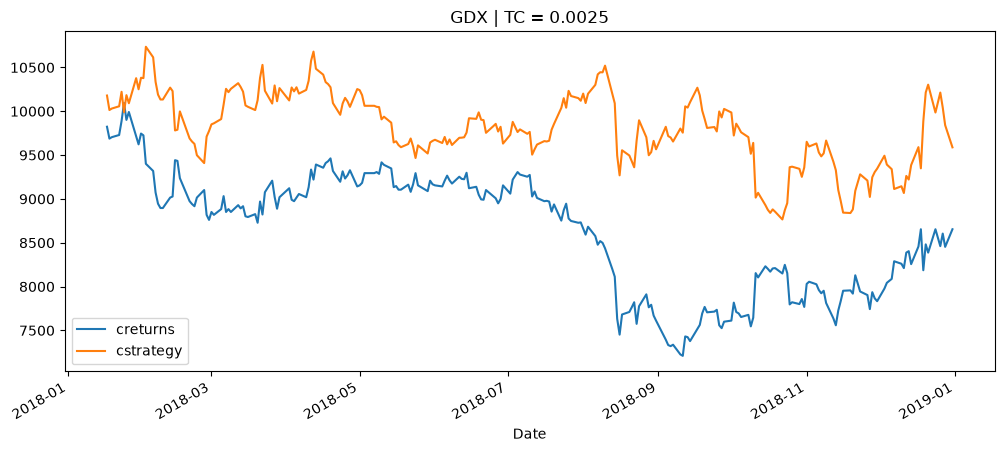

In [32]:
#样本外回测的结果
scibt.plot_results()

上面 `欧元/美元` 和书里印出来的不一样：

- 书里样本内 `(12192.18, 2189.5)`、样本外 `(10580.54, 729.93)`；
- 这里大约是 `(12480.37, 2477.7)` 和 `(10302.02, 451.4)`。样本外仍跑赢买入持有，幅度不同。

原因分两类：

- 库的更新：书用的是当时的 scikit-learn；现在 `lbfgs` 的 `tol` 作用在平均梯度上，默认停止更早，系数轨迹不同。`multi_class='ovr'` 在 1.9 已删掉。pandas3 链式赋值不再写回原表，交易成本改用 `.loc`。
- 本 notebook 的合理修改：方向策略只训 `±1`，拟合前丢掉收益为 0；用普通 `LogisticRegression(C=1e7)` 做二分类，不强行还原三类 `ovr`。


### 4.2 计算交易成本

本例把同一个策略应用到 GDX ETF 上，下图展示了它在样本外，不计交易成本时，跑赢基准的情况：


样本外回测方式: aperf = 12686.81 and operf = 4032.73


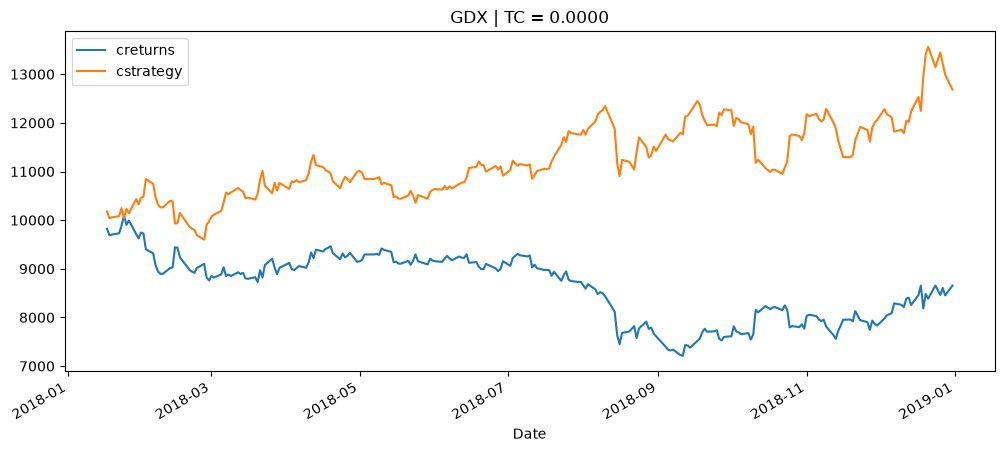

In [33]:
# 初始化模型
scibt = SCI.ScikitVectorBacktester(
    symbol='GDX',
    start='2010-1-1',
    end='2019-12-31',
    amount=10000,
    tc=0.00,
    model='logistic',
)

# 拟合窗在前、回测窗在后的训练回测方式
aperf, operf = scibt.run_strategy(
                            start_in='2013-1-1',
                            end_in='2017-12-31',
                            start_out='2018-1-1',
                            end_out='2018-12-31',
                            lags=10,
                            )
print("样本外回测方式: aperf =", aperf, "and operf =", operf)
# 书里: (12686.81, 4032.73)

scibt.plot_results()

下图展示了在保持其他参数不变的情况下，计入交易成本后，总体表现是如何被削弱的：

(np.float64(9588.48), np.float64(934.4))


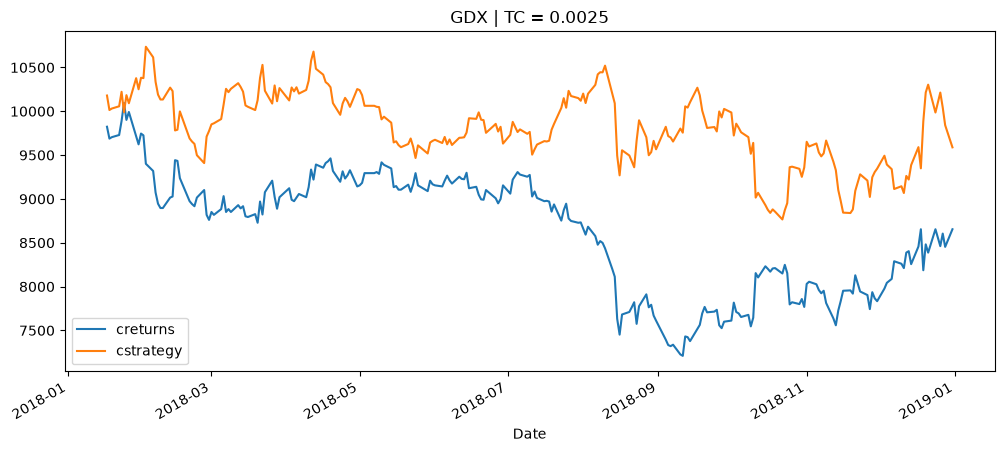

In [31]:
# 初始化模型
scibt = SCI.ScikitVectorBacktester(
    symbol='GDX',
    start='2010-1-1',
    end='2019-12-31',
    amount=10000,
    tc=0.0025,
    model='logistic',
)

# 拟合窗在前、回测窗在后的训练回测方式
aperf, operf = scibt.run_strategy(
                            start_in='2013-1-1',
                            end_in='2017-12-31',
                            start_out='2018-1-1',
                            end_out='2018-12-31',
                            lags=10,
                            )
print("样本外回测方式: aperf =", aperf, "and operf =", operf)
# 书里: (9588.48, 934.4)

scibt.plot_results()

- 相对本金：aperf = 9588 < 10000，绝对亏了大约 411，这个策略在样本外回测，计算交易成本时是净亏损的。
- 相对市场：但是相比买入持有，9588 - 8654 ≈ 934，说明这个策略相比单纯的买入持有，仍是高 934 的，比买入持有要更优。

一个策略可以一边亏损，一边比买入持有优秀。

> 将复杂的机器学习技术应用于股票市场预测，往往在一开始就能得到令人振奋的结果。在很多例子中，样本内回测会显著跑赢基础标的。这种“亮眼”表现，往往是若干简化假设与预测模型过拟合共同作用的结果。举例来说，如果不是在样本内、而是在样本外数据集上测试同一策略，并计入交易成本（为了得到更真实的结果），通常会发现该策略的表现会大幅回落。

## 5. 涨跌方向预测：二分类还是三分类？

本章采用 ±1 二分类，本质上是一种教学简化：假设每个交易日必须持有多头或空头仓位，以便于模型讲解和向量化回测的实现。但在实盘中，仓位状态不止“多”与“空”，还应包含“空仓”，因此有必要讨论标签设计上二分类与三分类的取舍。

- 二分类（+1 / −1）

最常见于教材与入门实现，标签通常取 sign(return) 或“下一期是否上涨”。其优点是建模与回测流程简单、可直接套用标准分类指标；局限在于隐含“市场每天都值得交易”的假设，无法表达空仓这一合理决策。

- 三分类（涨 / 跌 / 观望）

引入观望类别以后，标签设计通常依赖收益率阈值：超过正阈值记为上涨，低于负阈值记为下跌,区间内记为观望。这一做法更贴近真实交易决策，但存在两个实践难点：1. 阈值的选取带有主观性。 2. 观望类往往占绝大多数样本，导致类别分布严重不均衡，需要额外处理（如重采样或代价敏感学习）才能得到可靠模型。

部分实现选择将小幅波动样本直接剔除后再评估二分类指标，这种做法本质上回避了观望类的建模问题，而非真正解决它。

- 更严谨的标签体系：三重障碍与元标注（Meta-Labeling）

以 López de Prado 提出的三重障碍法（Triple-Barrier Method）为代表的一类方法，将问题拆分为两个阶段：先由主策略给出方向信号，再通过元标注单独判断该信号是否值得执行。这类方法更接近实际交易决策的逻辑，但相应地需要更完整的标注与验证流程，mlfinlab 等工具库对此有成熟实现,但已超出本章逻辑回归示例的讨论范围。

**三种方案对比**

| 方案 | 核心问题 | 主要局限 |
|---|---|---|
| 二分类 | 有仓位时方向是否正确 | 默认满仓多空，无法表达空仓 |
| 三分类 | 是否应当持仓及方向 | 阈值主观，类别分布不均衡 |
| 三重障碍与元标注 | 何时交易、信号是否可执行 | 流程复杂，实现与验证成本高 |
